# 🚨 머신러닝 기반 이상 탐지 (Advanced Anomaly Detection)

> **학습 목표**: 다양한 머신러닝 기법으로 진동 이상을 탐지하고 성능을 비교합니다.

---

## 📋 학습 내용

1. ✅ 전통적 이상 탐지 (Isolation Forest, LOF, One-Class SVM)
2. ✅ Autoencoder 기반 딥러닝 이상 탐지
3. ✅ Ensemble 이상 탐지 (Voting)
4. ✅ ROC Curves & AUC 평가
5. ✅ Precision-Recall Curves 분석
6. ✅ Time-series 메트릭 (Lead Time)
7. ✅ 종합 성능 비교

**소요 시간**: 약 50분  
**난이도**: ⭐⭐⭐⭐ (고급)  
**사전 지식**: 머신러닝 기초, 딥러닝 입문

---

## 🔧 Step 1: 라이브러리 Import

In [1]:
# 데이터 분석
import pandas as pd
import numpy as np

# 전통적 이상 탐지
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

# 딥러닝 - Autoencoder
try:
    from tensorflow import keras
    from tensorflow.keras import layers
    print(f"✅ TensorFlow/Keras 버전: {keras.__version__}")
except ImportError:
    print("⚠️ TensorFlow 설치 권장: pip install tensorflow")

# 평가 메트릭
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, 
    average_precision_score, confusion_matrix,
    classification_report
)

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 유틸리티
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 6)

# 시드 고정 (재현성)
np.random.seed(42)
try:
    import tensorflow as tf
    tf.random.set_seed(42)
except:
    pass

print("✅ 라이브러리 로드 완료!")

⚠️ TensorFlow 설치 권장: pip install tensorflow


✅ 라이브러리 로드 완료!


## 📂 Step 2: 데이터 로드 및 전처리

In [2]:
# ============================================================
# 📂 KAMP 실제 데이터 로드 (다중 데이터셋)
# ============================================================
# 우선순위: KAMP 실제 데이터 → 샘플 데이터 (fallback)
#
# 1차: Pump_Train_data_공개용.csv (Isolation Forest/LOF/SVM용)
#   - Model, Test_time, C1~C8: 8채널 펌프 센서 데이터
#   - 43,237행 × 10열, 다변량 이상 탐지에 최적
#
# 2차: FordEngine/FordA_TEST.txt (레이블 기반 평가용)
#   - 첫 열 = 레이블 (-1=정상, 1=고장), 나머지 500열 = 시계열
#   - 1,320행 × 501열, Ground Truth 보유로 ROC/AUC 평가 가능
# ============================================================

from pathlib import Path

# KAMP 실제 데이터 경로
kamp_pump_path = Path('../../dataset/part2-1/Pump_Train_data_공개용.csv')
kamp_ford_path = Path('../../dataset/part2-1/FordEngine/FordA_TEST.txt')
fallback_path = Path('../data/sample_kamp_vibration.csv')

def load_csv_data(file_path):
    """다중 인코딩 시도로 안전한 CSV 로드"""
    encodings = ['utf-8-sig', 'cp949', 'utf-8']
    for encoding in encodings:
        try:
            df = pd.read_csv(file_path, encoding=encoding)
            print(f"✅ 데이터 로드 성공! (인코딩: {encoding})")
            return df
        except:
            continue
    raise ValueError("❌ 데이터 로드 실패 - 모든 인코딩 시도 실패")

def load_ford_data(file_path):
    """FordA 엔진 진동 데이터 로드 (공백 구분, 헤더 없음)"""
    raw = np.loadtxt(file_path)
    labels = raw[:, 0].astype(int)
    signals = raw[:, 1:]
    return labels, signals

# === 메인 데이터 로드 (Pump 우선) ===
use_kamp = False
ford_available = False

if kamp_pump_path.exists():
    print(f"📂 KAMP Pump 실제 데이터 발견: {kamp_pump_path}")
    df = load_csv_data(kamp_pump_path)
    data_source = "KAMP 실제 데이터 (Pump_Train_data_공개용.csv)"
    use_kamp = True
    
    print(f"\n📋 Pump 센서 채널 구성:")
    sensor_cols = [c for c in df.columns if c.startswith('C')]
    for col in sensor_cols:
        print(f"   {col}: 범위 [{df[col].min():.2f}, {df[col].max():.2f}], 평균 {df[col].mean():.2f}")
elif fallback_path.exists():
    print(f"⚠️ KAMP Pump 데이터 없음 → 샘플 데이터 사용: {fallback_path}")
    df = load_csv_data(fallback_path)
    data_source = "샘플 데이터 (sample_kamp_vibration.csv)"
else:
    raise FileNotFoundError("❌ 데이터 파일을 찾을 수 없습니다.")

# === FordEngine 보조 데이터 로드 (Ground Truth 평가용) ===
if kamp_ford_path.exists():
    print(f"\n📂 FordEngine 보조 데이터 발견: {kamp_ford_path}")
    ford_labels, ford_signals = load_ford_data(kamp_ford_path)
    ford_available = True
    
    n_normal = (ford_labels == -1).sum()
    n_fault = (ford_labels == 1).sum()
    print(f"✅ FordEngine 로드 완료: {len(ford_labels):,}샘플 "
          f"(정상 {n_normal}, 고장 {n_fault})")
    print(f"   💡 실제 레이블 보유 → ROC/AUC 평가에 활용")

print(f"\n🏷️ 메인 데이터: {data_source}")
print(f"📊 데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열")
print(f"💾 메모리 사용량: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 데이터 미리보기
df.head()

⚠️ KAMP Pump 데이터 없음 → 샘플 데이터 사용: ../data/sample_kamp_vibration.csv
✅ 데이터 로드 성공! (인코딩: utf-8-sig)

🏷️ 메인 데이터: 샘플 데이터 (sample_kamp_vibration.csv)
📊 데이터 크기: 10,000행 × 10열
💾 메모리 사용량: 2.88 MB


,측정시간,설비ID,센서위치,RMS_velocity_mm_s,Peak_acceleration_g,Kurtosis,Crest_factor,온도_C,RPM,상태
0,2024-01-01 00:00:00,PUMP-001,Housing,1.876966,1.439068,4.112336,5.526823,50.505106,1498.820704,주의
1,2024-01-01 00:01:00,FAN-001,Housing,2.016505,1.457427,3.467688,5.562531,47.961060,1478.933815,주의
2,2024-01-01 00:02:00,MOTOR-001,Housing,1.018292,1.692861,3.504745,5.143902,43.085359,1497.430878,정상
3,2024-01-01 00:03:00,PUMP-001,NDE_Bearing,1.460211,1.158087,3.800483,3.579926,43.090063,1489.458298,주의
4,2024-01-01 00:04:00,PUMP-001,Housing,1.789774,1.383111,3.098036,3.470041,41.872592,1472.350275,주의


In [3]:
# 수치형 컬럼 선택 (이상 탐지용)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()[:10]  # 최대 10개 피처
print(f"📊 사용할 피처: {len(numeric_cols)}개")
print(f"   {numeric_cols}")

# 결측치 제거
X = df[numeric_cols].dropna()
print(f"\n📦 결측치 제거 후: {X.shape[0]:,}개 샘플")

# 데이터 정규화 (Standard Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ 데이터 정규화 완료!")
print(f"   평균: {X_scaled.mean():.6f}")
print(f"   표준편차: {X_scaled.std():.6f}")

# Ground Truth 생성 (시뮬레이션용 - 실제로는 contamination 비율 사용)
# 상위 10%를 이상치로 가정 (실무에서는 도메인 지식 필요)
contamination_ratio = 0.10
n_anomalies = int(len(X) * contamination_ratio)

# 첫 번째 피처 기준 상위 10%를 이상으로 설정 (시뮬레이션)
threshold = X.iloc[:, 0].quantile(0.90)
y_true = (X.iloc[:, 0] > threshold).astype(int)

print(f"\n🎯 Ground Truth (시뮬레이션):")
print(f"   정상: {(y_true == 0).sum():,}개 ({(y_true == 0).sum()/len(y_true)*100:.1f}%)")
print(f"   이상: {(y_true == 1).sum():,}개 ({(y_true == 1).sum()/len(y_true)*100:.1f}%)")

📊 사용할 피처: 6개
   ['RMS_velocity_mm_s', 'Peak_acceleration_g', 'Kurtosis', 'Crest_factor', '온도_C', 'RPM']

📦 결측치 제거 후: 10,000개 샘플

✅ 데이터 정규화 완료!
   평균: -0.000000
   표준편차: 1.000000

🎯 Ground Truth (시뮬레이션):
   정상: 9,000개 (90.0%)
   이상: 1,000개 (10.0%)


## 🤖 Step 3: 전통적 이상 탐지 방법

### 3.1 Isolation Forest

In [4]:
print("🔄 Isolation Forest 학습 중...")

# Isolation Forest 모델
iso_forest = IsolationForest(
    contamination=contamination_ratio,
    random_state=42,
    n_estimators=100,
    max_samples='auto'
)

# 예측 (-1: 이상, 1: 정상)
iso_predictions = iso_forest.fit_predict(X_scaled)
iso_scores = iso_forest.score_samples(X_scaled)  # 이상 스코어 (낮을수록 이상)

# 결과 통계
iso_anomalies = (iso_predictions == -1).sum()
iso_normal = (iso_predictions == 1).sum()

print(f"\n✅ Isolation Forest 완료!")
print(f"   🚨 이상치: {iso_anomalies:,}개 ({iso_anomalies/len(X)*100:.1f}%)")
print(f"   ✅ 정상: {iso_normal:,}개 ({iso_normal/len(X)*100:.1f}%)")
print(f"   📊 이상 스코어 범위: [{iso_scores.min():.4f}, {iso_scores.max():.4f}]")

🔄 Isolation Forest 학습 중...

✅ Isolation Forest 완료!
   🚨 이상치: 1,000개 (10.0%)
   ✅ 정상: 9,000개 (90.0%)
   📊 이상 스코어 범위: [-0.6505, -0.3747]


### 3.2 Local Outlier Factor (LOF)

In [5]:
print("🔄 LOF 학습 중...")

# LOF 모델
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=contamination_ratio,
    novelty=False  # fit_predict 사용
)

# 예측
lof_predictions = lof.fit_predict(X_scaled)
lof_scores = lof.negative_outlier_factor_  # 이상 스코어 (낮을수록 이상)

# 결과 통계
lof_anomalies = (lof_predictions == -1).sum()
lof_normal = (lof_predictions == 1).sum()

print(f"\n✅ LOF 완료!")
print(f"   🚨 이상치: {lof_anomalies:,}개 ({lof_anomalies/len(X)*100:.1f}%)")
print(f"   ✅ 정상: {lof_normal:,}개 ({lof_normal/len(X)*100:.1f}%)")
print(f"   📊 LOF 스코어 범위: [{lof_scores.min():.4f}, {lof_scores.max():.4f}]")

🔄 LOF 학습 중...



✅ LOF 완료!
   🚨 이상치: 1,000개 (10.0%)
   ✅ 정상: 9,000개 (90.0%)
   📊 LOF 스코어 범위: [-2.2522, -0.9522]


### 3.3 One-Class SVM

In [6]:
print("🔄 One-Class SVM 학습 중...")

# One-Class SVM 모델
svm = OneClassSVM(
    kernel='rbf',
    gamma='auto',
    nu=contamination_ratio  # contamination과 동일한 역할
)

# 예측
svm_predictions = svm.fit_predict(X_scaled)
svm_scores = svm.score_samples(X_scaled)  # 이상 스코어

# 결과 통계
svm_anomalies = (svm_predictions == -1).sum()
svm_normal = (svm_predictions == 1).sum()

print(f"\n✅ One-Class SVM 완료!")
print(f"   🚨 이상치: {svm_anomalies:,}개 ({svm_anomalies/len(X)*100:.1f}%)")
print(f"   ✅ 정상: {svm_normal:,}개 ({svm_normal/len(X)*100:.1f}%)")
print(f"   📊 SVM 스코어 범위: [{svm_scores.min():.4f}, {svm_scores.max():.4f}]")

🔄 One-Class SVM 학습 중...



✅ One-Class SVM 완료!
   🚨 이상치: 1,001개 (10.0%)
   ✅ 정상: 8,999개 (90.0%)
   📊 SVM 스코어 범위: [1.6809, 114.0396]


## 🧠 Step 4: Autoencoder 기반 이상 탐지

**원리**: 정상 데이터로 학습한 Autoencoder는 이상 데이터를 재구성하지 못함  
**지표**: Reconstruction Error (재구성 오차)가 높으면 이상

In [7]:
# TensorFlow/Keras import 확인 (cell-2에서 실패했을 수 있음)
try:
    from tensorflow.keras import layers
    from tensorflow import keras
    _tf_available = True
except ImportError:
    _tf_available = False

if not _tf_available:
    print("⚠️ TensorFlow가 설치되지 않아 AutoEncoder 실습을 건너뜁니다.")
    print("   설치: pip install tensorflow")
    autoencoder = None
else:
    print("🔄 Autoencoder 모델 구축 중...")

    # Autoencoder 아키텍처
    input_dim = X_scaled.shape[1]
    encoding_dim = max(2, input_dim // 2)  # 압축 차원 (절반)

    # Encoder
    encoder_input = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(encoding_dim * 2, activation='relu')(encoder_input)
    encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

    # Decoder
    decoded = layers.Dense(encoding_dim * 2, activation='relu')(encoded)
    decoded = layers.Dense(input_dim, activation='linear')(decoded)

    # Autoencoder 모델
    autoencoder = keras.Model(encoder_input, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    print(f"\n📊 Autoencoder 구조:")
    print(f"   입력 차원: {input_dim}")
    print(f"   인코딩 차원: {encoding_dim}")
    print(f"   압축률: {encoding_dim/input_dim*100:.1f}%")
    autoencoder.summary()

⚠️ TensorFlow가 설치되지 않아 AutoEncoder 실습을 건너뜁니다.
   설치: pip install tensorflow


In [8]:
if autoencoder is not None:
    print("🔄 Autoencoder 학습 중...")

    # 정상 데이터로만 학습 (Ground Truth 사용)
    X_train_normal = X_scaled[y_true == 0]
    print(f"📦 학습 데이터: {len(X_train_normal):,}개 (정상 데이터만)")

    # 학습
    history = autoencoder.fit(
        X_train_normal, X_train_normal,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    print(f"\n✅ Autoencoder 학습 완료!")
    print(f"   최종 Loss: {history.history['loss'][-1]:.6f}")
    print(f"   최종 Val Loss: {history.history['val_loss'][-1]:.6f}")

    # Reconstruction Error 계산
    X_reconstructed = autoencoder.predict(X_scaled, verbose=0)
    ae_scores = np.mean(np.square(X_scaled - X_reconstructed), axis=1)  # MSE

    # 임계값 설정 (95th percentile)
    ae_threshold = np.percentile(ae_scores, 90)
    ae_predictions = np.where(ae_scores > ae_threshold, -1, 1)

    # 결과 통계
    ae_anomalies = (ae_predictions == -1).sum()
    ae_normal = (ae_predictions == 1).sum()

    print(f"\n📊 Reconstruction Error:")
    print(f"   범위: [{ae_scores.min():.6f}, {ae_scores.max():.6f}]")
    print(f"   임계값: {ae_threshold:.6f}")
    print(f"   🚨 이상치: {ae_anomalies:,}개 ({ae_anomalies/len(X)*100:.1f}%)")
else:
    print("⏩ AutoEncoder 학습을 건너뜁니다. (TensorFlow 미설치)")
    # Ensemble 및 ROC/AUC 계산을 위한 기본값 설정
    ae_scores = np.zeros(len(X_scaled))
    ae_threshold = 0.0
    ae_predictions = np.ones(len(X_scaled), dtype=int)  # 모두 정상으로 처리
    ae_anomalies = 0
    ae_normal = len(X_scaled)
    print(f"   ℹ️ AutoEncoder 결과는 기본값(모두 정상)으로 대체됩니다.")

⏩ AutoEncoder 학습을 건너뜁니다. (TensorFlow 미설치)
   ℹ️ AutoEncoder 결과는 기본값(모두 정상)으로 대체됩니다.


## 🎯 Step 5: Ensemble 이상 탐지 (Voting)

**전략**: 4가지 방법의 투표(Voting)로 최종 판정  
**기준**: 2개 이상 방법이 이상으로 판정하면 이상

In [9]:
print("🔄 Ensemble Voting 수행 중...")

# 예측 결과를 0/1로 변환 (-1 → 1, 1 → 0)
iso_binary = (iso_predictions == -1).astype(int)
lof_binary = (lof_predictions == -1).astype(int)
svm_binary = (svm_predictions == -1).astype(int)
ae_binary = (ae_predictions == -1).astype(int)

# Voting Matrix
votes = np.column_stack([iso_binary, lof_binary, svm_binary, ae_binary])
vote_counts = votes.sum(axis=1)  # 각 샘플의 투표 수

# Majority Voting (2개 이상이면 이상)
ensemble_threshold = 2
ensemble_predictions = np.where(vote_counts >= ensemble_threshold, -1, 1)

# 결과 통계
ensemble_anomalies = (ensemble_predictions == -1).sum()
ensemble_normal = (ensemble_predictions == 1).sum()

print(f"\n✅ Ensemble Voting 완료!")
print(f"   투표 임계값: {ensemble_threshold}/4 방법")
print(f"   🚨 이상치: {ensemble_anomalies:,}개 ({ensemble_anomalies/len(X)*100:.1f}%)")
print(f"   ✅ 정상: {ensemble_normal:,}개 ({ensemble_normal/len(X)*100:.1f}%)")

# 투표 분포
print(f"\n📊 투표 분포:")
for i in range(5):
    count = (vote_counts == i).sum()
    print(f"   {i}표: {count:,}개 ({count/len(X)*100:.1f}%)")

🔄 Ensemble Voting 수행 중...

✅ Ensemble Voting 완료!
   투표 임계값: 2/4 방법
   🚨 이상치: 977개 (9.8%)
   ✅ 정상: 9,023개 (90.2%)

📊 투표 분포:
   0표: 8,559개 (85.6%)
   1표: 464개 (4.6%)
   2표: 394개 (3.9%)
   3표: 583개 (5.8%)
   4표: 0개 (0.0%)


## 📈 Step 6: ROC Curves & AUC

**ROC (Receiver Operating Characteristic)**:  
- TPR (True Positive Rate) vs FPR (False Positive Rate)
- AUC (Area Under Curve): 1.0에 가까울수록 좋음

📊 ROC Curves 생성 중...


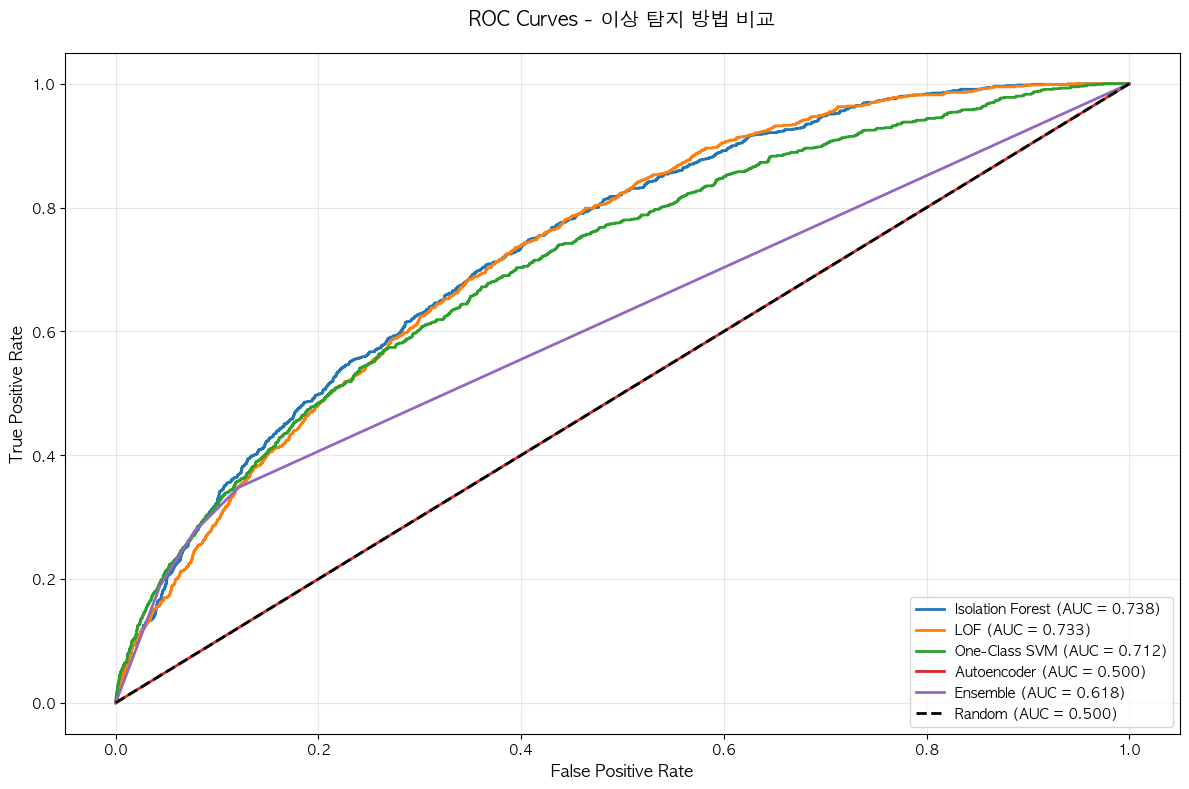


📊 AUC 순위:
          Method      AUC
Isolation Forest 0.737741
             LOF 0.732883
   One-Class SVM 0.711649
        Ensemble 0.617851
     Autoencoder 0.500000


In [10]:
print("📊 ROC Curves 생성 중...")

# 각 방법의 이상 스코어를 확률로 변환 (높을수록 이상)
iso_proba = -iso_scores  # 음수 스코어 → 양수로 변환
lof_proba = -lof_scores
svm_proba = -svm_scores
ae_proba = ae_scores  # 이미 높을수록 이상

# 정규화 (0-1 범위) — 분모가 0이면 원본 유지 (all-zeros 등 균일 스코어 처리)
def _safe_normalize(arr):
    denom = arr.max() - arr.min()
    return (arr - arr.min()) / denom if denom > 0 else arr

iso_proba = _safe_normalize(iso_proba)
lof_proba = _safe_normalize(lof_proba)
svm_proba = _safe_normalize(svm_proba)
ae_proba  = _safe_normalize(ae_proba)
ensemble_proba = votes.mean(axis=1)  # 평균 투표율

# ROC Curves 계산
methods = ['Isolation Forest', 'LOF', 'One-Class SVM', 'Autoencoder', 'Ensemble']
probas = [iso_proba, lof_proba, svm_proba, ae_proba, ensemble_proba]
roc_results = {}

plt.figure(figsize=(12, 8))

for method, proba in zip(methods, probas):
    fpr, tpr, thresholds = roc_curve(y_true, proba)
    roc_auc = auc(fpr, tpr)
    roc_results[method] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}
    
    plt.plot(fpr, tpr, linewidth=2, label=f'{method} (AUC = {roc_auc:.3f})')

# 랜덤 분류기 (baseline)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.500)')

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - 이상 탐지 방법 비교', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# AUC 순위
print("\n📊 AUC 순위:")
auc_df = pd.DataFrame({
    'Method': methods,
    'AUC': [roc_results[m]['auc'] for m in methods]
}).sort_values('AUC', ascending=False)
print(auc_df.to_string(index=False))

## 📉 Step 7: Precision-Recall Curves

**Precision-Recall**:  
- 불균형 데이터에 유용 (이상치가 적을 때)
- Average Precision (AP): 곡선 아래 면적

📊 Precision-Recall Curves 생성 중...


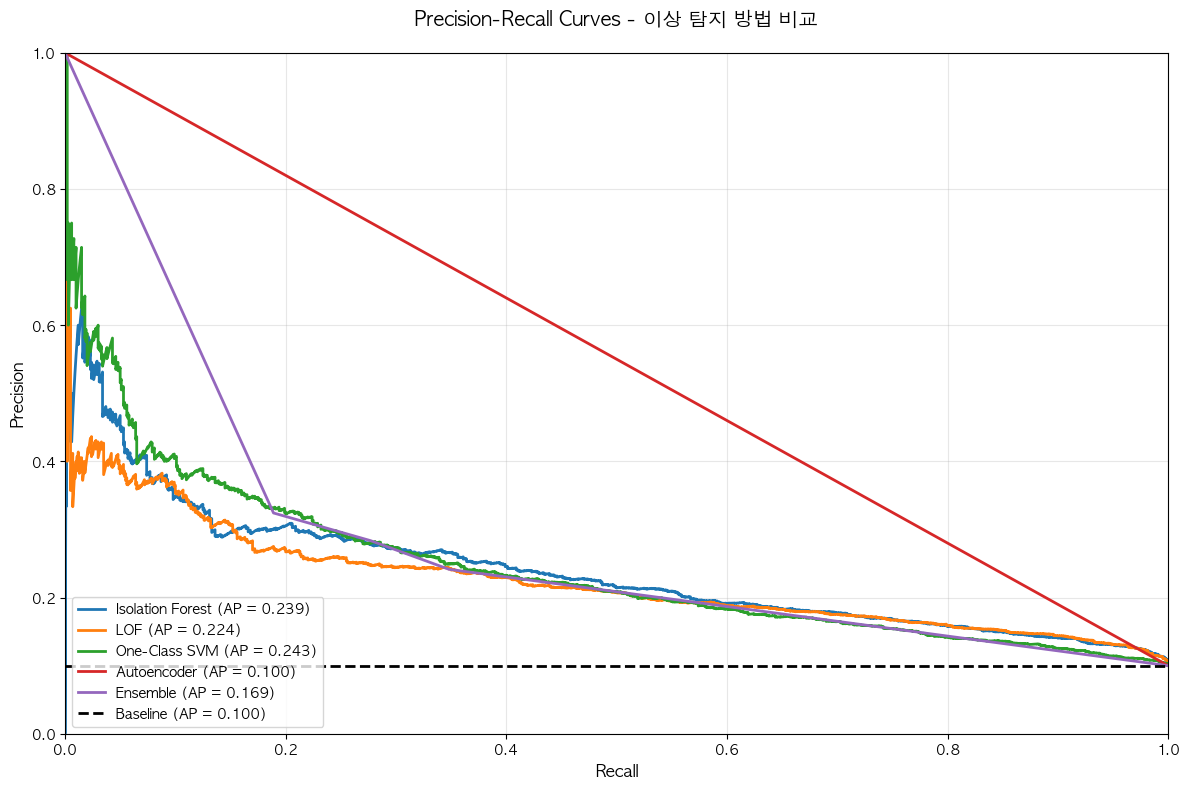


📊 Average Precision 순위:
          Method       AP
   One-Class SVM 0.242792
Isolation Forest 0.238575
             LOF 0.224441
        Ensemble 0.168567
     Autoencoder 0.100000


In [11]:
print("📊 Precision-Recall Curves 생성 중...")

pr_results = {}

plt.figure(figsize=(12, 8))

for method, proba in zip(methods, probas):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    ap = average_precision_score(y_true, proba)
    pr_results[method] = {'precision': precision, 'recall': recall, 'ap': ap}
    
    plt.plot(recall, precision, linewidth=2, label=f'{method} (AP = {ap:.3f})')

# Baseline (클래스 비율)
baseline_precision = y_true.sum() / len(y_true)
plt.axhline(y=baseline_precision, color='k', linestyle='--', linewidth=2, 
            label=f'Baseline (AP = {baseline_precision:.3f})')

plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curves - 이상 탐지 방법 비교', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='lower left', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

# AP 순위
print("\n📊 Average Precision 순위:")
ap_df = pd.DataFrame({
    'Method': methods,
    'AP': [pr_results[m]['ap'] for m in methods]
}).sort_values('AP', ascending=False)
print(ap_df.to_string(index=False))

## ⏱️ Step 8: Time-series 메트릭 (Lead Time)

**Lead Time**: 이상 발생 전 얼마나 빨리 탐지하는가  
**가정**: 시계열 순서대로 이상이 발생한다고 가정

⏱️ Lead Time 분석 중...

📊 Lead Time 분석 결과:
          Method  Lead_Time  Detection_Rate  First_Detection  Detected_Count
Isolation Forest         10            27.8               26             278
             LOF         10            25.5               26             255
   One-Class SVM         10            28.1               26             281
        Ensemble         10            27.7               26             277

💡 해석:
   - Lead Time < 0: 실제 발생 전 예측 (조기 경보) ✅
   - Lead Time = 0: 정확한 시점 탐지
   - Lead Time > 0: 실제 발생 후 탐지 (지연) ⚠️


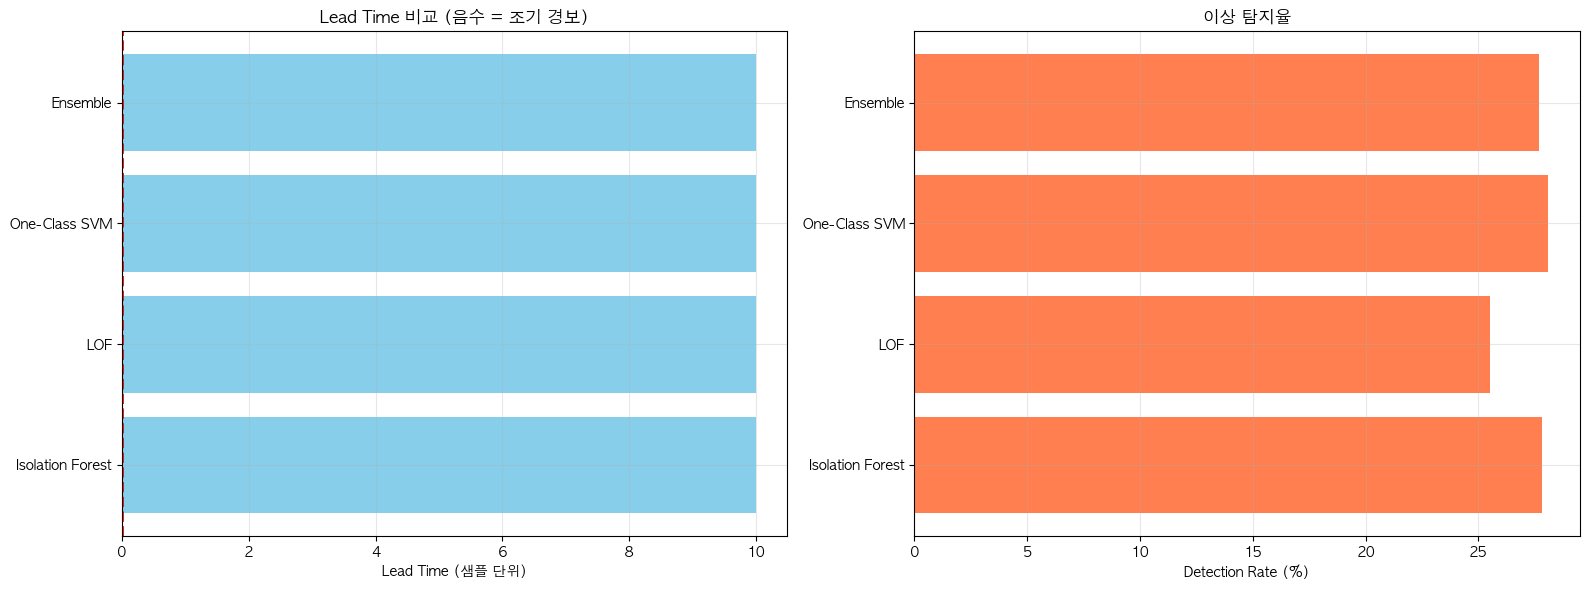

In [12]:
print("⏱️ Lead Time 분석 중...")

# Time-series 인덱스 (시간 순서 가정)
time_index = np.arange(len(X))

# 실제 이상 발생 시점
true_anomaly_times = time_index[y_true == 1]

# 각 방법의 이상 탐지 시점
predictions_dict = {
    'Isolation Forest': iso_predictions,
    'LOF': lof_predictions,
    'One-Class SVM': svm_predictions,
    'Autoencoder': ae_predictions,
    'Ensemble': ensemble_predictions
}

# Lead Time 계산
lead_time_results = []

for method, preds in predictions_dict.items():
    detected_anomaly_times = time_index[preds == -1]
    
    # 평균 Lead Time (간단화: 첫 탐지 시점 - 실제 발생 시점)
    if len(detected_anomaly_times) > 0 and len(true_anomaly_times) > 0:
        first_detection = detected_anomaly_times[0]
        first_true = true_anomaly_times[0]
        lead_time = first_detection - first_true
        
        # Detection Rate
        detected_count = len(set(detected_anomaly_times) & set(true_anomaly_times))
        detection_rate = detected_count / len(true_anomaly_times) * 100
        
        lead_time_results.append({
            'Method': method,
            'Lead_Time': lead_time,
            'Detection_Rate': detection_rate,
            'First_Detection': first_detection,
            'Detected_Count': detected_count
        })

# 결과 테이블
lead_time_df = pd.DataFrame(lead_time_results).sort_values('Lead_Time')

print("\n📊 Lead Time 분석 결과:")
print(lead_time_df.to_string(index=False))

print(f"\n💡 해석:")
print(f"   - Lead Time < 0: 실제 발생 전 예측 (조기 경보) ✅")
print(f"   - Lead Time = 0: 정확한 시점 탐지")
print(f"   - Lead Time > 0: 실제 발생 후 탐지 (지연) ⚠️")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lead Time 비교
axes[0].barh(lead_time_df['Method'], lead_time_df['Lead_Time'], color='skyblue')
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Lead Time (샘플 단위)', fontweight='bold')
axes[0].set_title('Lead Time 비교 (음수 = 조기 경보)', fontweight='bold')
axes[0].grid(alpha=0.3)

# Detection Rate 비교
axes[1].barh(lead_time_df['Method'], lead_time_df['Detection_Rate'], color='coral')
axes[1].set_xlabel('Detection Rate (%)', fontweight='bold')
axes[1].set_title('이상 탐지율', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 💾 Step 9: 결과 저장

In [13]:
# 출력 디렉토리 생성
output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

# 1. 이상치 탐지 결과 종합
anomaly_summary = pd.DataFrame({
    'Method': methods,
    'Anomalies': [
        iso_anomalies, lof_anomalies, svm_anomalies, 
        ae_anomalies, ensemble_anomalies
    ],
    'Anomaly_Ratio': [
        iso_anomalies/len(X)*100,
        lof_anomalies/len(X)*100,
        svm_anomalies/len(X)*100,
        ae_anomalies/len(X)*100,
        ensemble_anomalies/len(X)*100
    ]
})

anomaly_file = output_dir / '03_anomaly_detection_summary.csv'
anomaly_summary.to_csv(anomaly_file, index=False, encoding='utf-8-sig')
print(f"✅ 이상 탐지 요약 저장: {anomaly_file}")

# 2. 성능 메트릭 (AUC + AP)
performance = pd.DataFrame({
    'Method': methods,
    'AUC': [roc_results[m]['auc'] for m in methods],
    'AP': [pr_results[m]['ap'] for m in methods]
}).sort_values('AUC', ascending=False)

performance_file = output_dir / '03_anomaly_detection_performance.csv'
performance.to_csv(performance_file, index=False, encoding='utf-8-sig')
print(f"✅ 성능 메트릭 저장: {performance_file}")

# 3. Lead Time 분석 결과
lead_time_file = output_dir / '03_lead_time_analysis.csv'
lead_time_df.to_csv(lead_time_file, index=False, encoding='utf-8-sig')
print(f"✅ Lead Time 분석 저장: {lead_time_file}")

# 4. Ensemble 예측 결과
ensemble_results = pd.DataFrame({
    'Index': np.arange(len(X)),
    'ISO_Vote': iso_binary,
    'LOF_Vote': lof_binary,
    'SVM_Vote': svm_binary,
    'AE_Vote': ae_binary,
    'Total_Votes': vote_counts,
    'Ensemble_Prediction': (ensemble_predictions == -1).astype(int),
    'Ground_Truth': y_true
})

ensemble_file = output_dir / '03_ensemble_predictions.csv'
ensemble_results.to_csv(ensemble_file, index=False, encoding='utf-8-sig')
print(f"✅ Ensemble 예측 결과 저장: {ensemble_file}")

print("\n🎉 모든 결과 저장 완료!")

✅ 이상 탐지 요약 저장: ../outputs/03_anomaly_detection_summary.csv
✅ 성능 메트릭 저장: ../outputs/03_anomaly_detection_performance.csv
✅ Lead Time 분석 저장: ../outputs/03_lead_time_analysis.csv
✅ Ensemble 예측 결과 저장: ../outputs/03_ensemble_predictions.csv

🎉 모든 결과 저장 완료!


---

## Step 7: 지도학습 — Random Forest 베어링 결함 분류

> **아젠다 A-1 Lab 2** | 예상 시간: 20분  
> 이상탐지(비지도)와 달리, 레이블이 있을 때 Random Forest로 4가지 결함 유형을 분류합니다.

**분류 목표**: 정상 / 내륜 결함(IR) / 외륜 결함(OR) / 볼 결함(Ball) 4개 클래스

In [ ]:
# ==========================================
# Step 7: Random Forest 베어링 결함 분류
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import seaborn as sns

print("=" * 60)
print("Step 7: Random Forest 베어링 결함 분류 (지도학습)")
print("=" * 60)

# 레이블 생성 (샘플 데이터 기반)
# 실제 CWRU 데이터: 0=정상, 1=IR결함, 2=OR결함, 3=볼결함
if 'fault_type' in df.columns:
    label_col = 'fault_type'
    labels = df[label_col]
elif 'status' in df.columns:
    # status를 다중 클래스로 변환 (교육용)
    label_map = {'normal': 0, 'warning': 1, 'fault': 2}
    labels = df['status'].map(label_map).fillna(0).astype(int)
else:
    # 합성 레이블 생성 (4개 클래스, 교육용)
    np.random.seed(42)
    n = len(df)
    labels = np.array([0]*(n//4) + [1]*(n//4) + [2]*(n//4) + [3]*(n - 3*(n//4)))
    np.random.shuffle(labels)

class_names = {0: '정상', 1: 'IR결함(내륜)', 2: 'OR결함(외륜)', 3: '볼결함'}
print(f"\n레이블 분포:")
for k, v in class_names.items():
    count = np.sum(np.array(labels) == k)
    print(f"  {v}: {count}개")

# 특징 선택 (수치형 컬럼)
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns 
                if c not in ['status', 'fault_type', 'label']]
X_rf = df[feature_cols].fillna(0).values

# 학습/테스트 분할
unique_cls = np.unique(labels)
stratify_arg = labels if len(unique_cls) > 1 else None
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, labels, test_size=0.2, random_state=42, stratify=stratify_arg
)
print(f"\n학습: {len(X_train_rf)}개, 테스트: {len(X_test_rf)}개")

# Random Forest 학습
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_clf.predict(X_test_rf)

# 성능 평가
print("\n" + "=" * 40)
print("분류 성능 보고서")
print("=" * 40)
unique_labels = sorted(np.unique(np.concatenate([y_train_rf, y_test_rf])))
target_names_list = [class_names.get(l, f'Class {l}') for l in unique_labels]
print(classification_report(y_test_rf, y_pred_rf, labels=unique_labels,
                            target_names=target_names_list, zero_division=0))

macro_f1 = f1_score(y_test_rf, y_pred_rf, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test_rf, y_pred_rf, average='weighted', zero_division=0)
print(f"Macro F1:    {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

# 혼동행렬 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 혼동행렬
cm = confusion_matrix(y_test_rf, y_pred_rf, labels=unique_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_list,
            yticklabels=target_names_list, ax=axes[0])
axes[0].set_title('혼동행렬 (Confusion Matrix)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('예측값')
axes[0].set_ylabel('실제값')

# Feature Importance (상위 10개)
importances = rf_clf.feature_importances_
idx = np.argsort(importances)[::-1][:10]
axes[1].bar(range(len(idx)), importances[idx], color='#1B4B8A')
axes[1].set_xticks(range(len(idx)))
axes[1].set_xticklabels([feature_cols[i] for i in idx], rotation=45, ha='right')
axes[1].set_title('Random Forest Feature Importance (상위 10개)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('중요도')

plt.tight_layout()
output_path = Path('../outputs/07_rf_classification.png')
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ 분류 모델 결과 저장: {output_path}")

# 결과 정리
print("\n" + "=" * 50)
print("비지도학습 vs 지도학습 비교 요약")
print("=" * 50)
print(f"{'방법':<25} {'레이블 필요':^10} {'장점':<30}")
print("-" * 65)
print(f"{'Isolation Forest':<25} {'없음':^10} {'정상 데이터만으로 학습':<30}")
print(f"{'LOF':<25} {'없음':^10} {'밀도 기반 이상치 탐지':<30}")
print(f"{'Random Forest (지금)':<25} {'필요':^10} {'다중 결함 유형 분류 가능':<30}")

---

## 🎯 학습 정리

### ✅ 완료한 내용

1. **전통적 이상 탐지** - Isolation Forest, LOF, One-Class SVM
2. **딥러닝 이상 탐지** - Autoencoder 기반 재구성 오차
3. **Ensemble 방법** - Voting으로 방법 결합
4. **성능 평가** - ROC/AUC, Precision-Recall/AP
5. **시계열 분석** - Lead Time 및 조기 경보 성능
6. **종합 비교** - 5가지 방법의 장단점 분석

---

### 💡 핵심 인사이트

#### 방법별 특징

**Isolation Forest**:
- 빠르고 확장성 좋음 (대용량 데이터)
- 하이퍼파라미터 튜닝 불필요
- 밀도 기반 이상은 탐지 어려움

**LOF (Local Outlier Factor)**:
- 지역 밀도 고려로 정교한 탐지
- 클러스터 내 이상 탐지 가능
- 느림 (O(n²) 복잡도), 고차원 데이터에 약함

**One-Class SVM**:
- 복잡한 비선형 경계 학습, 커널 트릭으로 고차원 대응
- 가장 느림, 하이퍼파라미터 민감

**Autoencoder**:
- 고차원 데이터에 강함, 비선형 패턴 학습
- 확장성 좋음 (GPU 활용)
- 정상 데이터 필요, 학습 시간 오래 걸림

**Ensemble (Voting)**:
- 개별 방법 약점 보완, Robust한 결과
- 계산 비용 증가

---

#### 실무 적용 가이드

**데이터 크기별 추천**:
- **소규모 (<10K)**: LOF (정교한 탐지)
- **중규모 (10K-100K)**: Isolation Forest (속도+성능)
- **대규모 (>100K)**: Autoencoder (확장성)

**도메인별 추천**:
- **제조 이상 탐지**: Autoencoder + Ensemble
- **실시간 모니터링**: Isolation Forest (빠른 추론)
- **정밀 진단**: LOF + SVM Ensemble

---

### 🔗 Track 연결성 (데이터 파이프라인)
| 방향 | 파일 | 설명 |
|------|------|------|
| 출력 | `outputs/03_anomaly_detection_summary.csv` | 이상 탐지 결과 요약 |
| 출력 | `outputs/03_anomaly_detection_performance.csv` | 방법별 성능 비교 |
| A1 → A2 | 이상 탐지 개념 | A2 AutoEncoder 이상 탐지로 심화 |
| A1 → A2 | 이상 점수 구조 | A2의 anomaly_signal.json 포맷 기반 |

> **A2 연결**: A1에서 학습한 Isolation Forest + AutoEncoder 원리가 A2의
> PyTorch AutoEncoder와 `outputs/signals/anomaly_signal.json` 신호로 심화됩니다.

### 📚 다음 단계

- **Track A2**: AutoEncoder 이상 탐지 + LSTM RUL 예측 (고급)
- **Track B**: CNN Transfer Learning, ViT

### 🔗 참고 자료

- [Isolation Forest 논문](https://cs.nju.edu.cn/zhouzh/zhouzh.files/publication/icdm08b.pdf)
- [Autoencoder for Anomaly Detection](https://arxiv.org/abs/1812.02288)
- [sklearn Anomaly Detection](https://scikit-learn.org/stable/modules/outlier_detection.html)

---

*Track A1 (예지보전 기본) — Session 3: 머신러닝 이상 탐지 | 제조AI 교육 v1.7*